In [23]:
# https://medium.com/@RobuRishabh/understanding-and-implementing-faster-r-cnn-248f7b25ff96

In [ ]:
import cv2
import random
import os
import numpy as np

Initialization of image
1. kernel size for gausian blur
2. binary threshold
3. box area min, max

# Configuration  

In [ ]:
# ---------------- CONFIG ----------------

class Config:
    Dataset_src = r"D:\Himanshu_ML\TE_UAV Data\TE_defected\cat_defect1_data"

    TRAIN_IMAGE_DIR = os.path.join(Dataset_src, "train")
    TRAIN_ANNOTATION_PATH = os.path.join(TRAIN_IMAGE_DIR, "_annotations.coco.json")

    VAL_IMAGE_DIR = os.path.join(Dataset_src, "valid")
    VAL_ANNOTATION_PATH = os.path.join(VAL_IMAGE_DIR, "_annotations.coco.json")

    NUM_EPOCHS = 50
    BATCH_SIZE = 4
    LR = 1e-4
    WD = 1e-4

    FG_IOU = 0.5
    BG_IOU = 0.3
    BATCH_PER_IMG = 256
    POSITIVE_FRACTION = 0.5
    PRE_NMS_TRAIN = 2000
    PRE_NMS_TEST = 1000
    POST_NMS_TRAIN = 2000
    POST_NMS_TEST = 300
    NMS_THRESH = 0.7


# Preprocessing

In [26]:
from typing import Tuple

In [27]:
# ---------------- PREPROCESSING ----------------
class Preprocessing:
    """Lightweight preprocessing for defect detection."""
    def __init__(self, use_clahe=True, use_flip=True, use_brightness=True):
        self.use_clahe = use_clahe
        self.use_flip = use_flip
        self.use_brightness = use_brightness

    def __call__(self, img: np.ndarray) -> np.ndarray:
        processed_img = img.copy()

        # CLAHE
        if self.use_clahe:
            lab = cv2.cvtColor(processed_img, cv2.COLOR_BGR2LAB)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            lab[:, :, 0] = clahe.apply(lab[:, :, 0])
            processed_img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

        # Random horizontal flip
        if self.use_flip and random.random() > 0.5:
            processed_img = cv2.flip(processed_img, 1)

        # Random brightness
        if self.use_brightness:
            factor = 1.0 + (random.random() - 0.5) * 0.2
            processed_img = np.clip(processed_img * factor, 0, 255).astype(np.uint8)

        return processed_img


# CBAM (Channel + Spatial)

In [28]:
import torch
import torchvision
import torch.nn as nn
from torchvision.ops import DeformConv2d

Channel Attention

In [29]:
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_planes, in_planes // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_planes // reduction, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return x * self.sigmoid(self.fc(x))

Spatial Attention

In [30]:
class SpatialAttention(nn.Module):
    def __init__(self, kernel=7):
        super().__init__()
        pad = (kernel - 1) // 2
        self.conv = nn.Conv2d(2, 1, kernel, padding=pad, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        max_, _ = x.max(dim=1, keepdim=True)
        attn = torch.cat([avg, max_], dim=1)
        attn = self.sigmoid(self.conv(attn))
        return x * attn


Channel+Spatial

In [31]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x

# Feature Map (ResNet architecture)

In [32]:
from collections import OrderedDict
import torch.nn.functional as F

In [33]:
class CustomBackboneWithFPN(nn.Module):
    def __init__(self):
        super().__init__()
        base = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)
        self.stage1 = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.stage2 = base.layer1
        self.stage3 = base.layer2
        self.stage4 = base.layer3
        self.stage5 = base.layer4

        self.l5 = nn.Conv2d(2048, 256, 1)
        self.l4 = nn.Conv2d(1024, 256, 1)
        self.l3 = nn.Conv2d(512, 256, 1)
        self.l2 = nn.Conv2d(256, 256, 1)

        self.s4 = nn.Conv2d(256, 256, 3, padding=1)
        self.s3 = nn.Conv2d(256, 256, 3, padding=1)
        self.s2 = nn.Conv2d(256, 256, 3, padding=1)

        self.deform = DeformConv2d(256, 256, 3, padding=1)
        self.cbam = CBAM(256)

    def _upsample_add(self, x, y):
        return F.interpolate(x, size=y.shape[-2:], mode='nearest') + y

    def forward(self, x):
        c1 = self.stage1(x)
        c2 = self.stage2(c1)
        c3 = self.stage3(c2)
        c4 = self.stage4(c3)
        c5 = self.stage5(c4)

        p5 = self.l5(c5)
        p4 = self._upsample_add(p5, self.l4(c4))
        p3 = self._upsample_add(p4, self.l3(c3))
        p2 = self._upsample_add(p3, self.l2(c2))

        offset = torch.zeros(
            p5.shape[0], 2 * 3 * 3, p5.shape[2], p5.shape[3],
            device=p5.device, dtype=p5.dtype
        )
        p5 = self.cbam(self.deform(p5, offset))
        p4, p3, p2 = self.s4(p4), self.s3(p3), self.s2(p2)

        return OrderedDict({"0": p2, "1": p3, "2": p4, "3": p5})

# Data Annotation

In [34]:
import json
from typing import Tuple, List, Dict, Any
import os

In [35]:
def load_coco_data(json_path: str, image_dir: str) -> Tuple[List[Dict[str, Any]], int]:
    """
    Parses a COCO JSON file and structures the data for the custom dataset.
    Returns a list of dictionaries, where each dict contains image path and annotations.
    """
    with open(json_path, 'r') as f:
        coco_data = json.load(f)

    # Map image IDs to file names and category IDs to labels
    id_to_filename = {img['id']: img['file_name'] for img in coco_data['images']}
    
    # Store annotations by image ID
    annotations_by_image = {}
    for ann in coco_data['annotations']:
        image_id = ann['image_id']
        if image_id not in annotations_by_image:
            annotations_by_image[image_id] = {'boxes': [], 'labels': []}
        
        # COCO bbox format is [x_min, y_min, width, height]
        # Convert it to [x_min, y_min, x_max, y_max] and store as a list
        bbox = ann['bbox']
        x_min, y_min, width, height = bbox
        annotations_by_image[image_id]['boxes'].append([x_min, y_min, x_min + width, y_min + height])
        annotations_by_image[image_id]['labels'].append(ann['category_id'])

    # Final list of data dictionaries
    dataset_list = []
    for image_id, anns in annotations_by_image.items():
        image_path = os.path.join(image_dir, id_to_filename[image_id])
        dataset_list.append({
            'image_path': image_path,
            'boxes': torch.tensor(anns['boxes'], dtype=torch.float32),
            'labels': torch.tensor(anns['labels'], dtype=torch.int64)
        })
    
    # +1 for the background class
    num_classes = len(coco_data['categories']) + 1 
    return dataset_list, num_classes


# Dataset & Annotation

In [36]:
import os
from torchvision.transforms import functional as TF
from torch.utils.data import Dataset, DataLoader

In [37]:
# ---------------- DATASET ----------------
from torchvision import transforms

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

class DroneDefectDataset(Dataset):
    def __init__(self, data_list, preprocess=None):
        self.data_list = data_list
        self.preprocess = preprocess

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        item = self.data_list[idx]
        img_path = item['image_path']
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.preprocess:
            img = self.preprocess(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

        img_tensor = TF.to_tensor(img)
        img_tensor = normalize(img_tensor)

        target = {
            'boxes': item['boxes'],
            'labels': item['labels']
        }
        return img_tensor, target


# Model Construction & Training

In [38]:
def collate_fn(batch):
    return tuple(zip(*batch))

Anchor Generator

In [39]:
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator, RPNHead, RegionProposalNetwork
from torchvision.ops import MultiScaleRoIAlign

In [40]:
def build_model(num_classes):
    backbone = CustomBackboneWithFPN()
    backbone.out_channels = 256

    anchor_gen = AnchorGenerator(
        sizes=((32,), (64,), (128,), (256,)),
        aspect_ratios=((0.5, 1.0, 2.0),) * 4
    )
    num_anchors = anchor_gen.num_anchors_per_location()[0]
    rpn_head = RPNHead(256, num_anchors)

    rpn = RegionProposalNetwork(
        anchor_generator=anchor_gen,
        head=rpn_head,
        fg_iou_thresh=Config.FG_IOU,
        bg_iou_thresh=Config.BG_IOU,
        batch_size_per_image=Config.BATCH_PER_IMG,
        positive_fraction=Config.POSITIVE_FRACTION,
        pre_nms_top_n={"training": Config.PRE_NMS_TRAIN, "testing": Config.PRE_NMS_TEST},
        post_nms_top_n={"training": Config.POST_NMS_TRAIN, "testing": Config.POST_NMS_TEST},
        nms_thresh=Config.NMS_THRESH
    )

    roi_pool = MultiScaleRoIAlign(
        featmap_names=["0", "1", "2", "3"],
        output_size=7,
        sampling_ratio=2
    )

    model = FasterRCNN(
        backbone=backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_gen,
        box_roi_pool=roi_pool,
        image_mean=[0.485, 0.456, 0.406],
        image_std=[0.229, 0.224, 0.225]
    )
    model.rpn = rpn
    return model

# Model Training

In [41]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    for batch_idx, (imgs, targets) in enumerate(loader):
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        print(f"Batch {batch_idx+1}/{len(loader)} - Loss: {loss.item():.4f}")

    return running_loss

# Main Fun

In [42]:
import yaml
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [43]:
# ---------------- TRAINING MAIN ----------------
if __name__ == '__main__':
    cfg = Config()

    print("Loading training data...")
    train_data_list, num_classes = load_coco_data(cfg.TRAIN_ANNOTATION_PATH, cfg.TRAIN_IMAGE_DIR)
    print("Loading validation data...")
    val_data_list, _ = load_coco_data(cfg.VAL_ANNOTATION_PATH, cfg.VAL_IMAGE_DIR)
    print(f"Total classes (with background): {num_classes}")

    prep = Preprocessing()
    train_ds = DroneDefectDataset(train_data_list, preprocess=prep)
    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE,
                              shuffle=True, collate_fn=collate_fn)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = build_model(num_classes)
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WD)

    for epoch in range(cfg.NUM_EPOCHS):
        loss = train_one_epoch(model, train_loader, optimizer, device)
        print(f"Epoch {epoch+1}/{cfg.NUM_EPOCHS} - Avg Loss: {loss/len(train_loader):.4f}")

    torch.save(model.state_dict(), 'part_drone_detection.pth')
    print("✅ Model saved as 'part_drone_detection.pth'")


Loading training data...
Loading validation data...
Total classes (with background): 7
Batch 1/801 - Loss: 2.8168
Batch 2/801 - Loss: 1.4512
Batch 3/801 - Loss: 1.7032
Batch 4/801 - Loss: 1.1951
Batch 5/801 - Loss: 0.9041
Batch 6/801 - Loss: 0.7982
Batch 7/801 - Loss: 1.0192
Batch 8/801 - Loss: 0.6967
Batch 9/801 - Loss: 0.6080
Batch 10/801 - Loss: 0.6653
Batch 11/801 - Loss: 0.4991
Batch 12/801 - Loss: 2.2898
Batch 13/801 - Loss: 0.4126
Batch 14/801 - Loss: 1.4516
Batch 15/801 - Loss: 0.6895
Batch 16/801 - Loss: 0.4295
Batch 17/801 - Loss: 0.5189
Batch 18/801 - Loss: 0.7332
Batch 19/801 - Loss: 0.4982
Batch 20/801 - Loss: 0.5424
Batch 21/801 - Loss: 0.6950
Batch 22/801 - Loss: 0.3613
Batch 23/801 - Loss: 0.4043
Batch 24/801 - Loss: 0.6486
Batch 25/801 - Loss: 0.6482
Batch 26/801 - Loss: 0.4871
Batch 27/801 - Loss: 0.5532
Batch 28/801 - Loss: 0.4847
Batch 29/801 - Loss: 0.6829
Batch 30/801 - Loss: 0.6628
Batch 31/801 - Loss: 0.4867
Batch 32/801 - Loss: 0.7624
Batch 33/801 - Loss: 0.500

# Testing

In [2]:
import torch
import torchvision
from torchvision.transforms import functional as F
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from frcn_bdy import build_model, Config

In [6]:
mod_pth = r"D:\Himanshu_ML\TE_UAV Projects\TE_1 UAV MRO\UAV_Dft\part_drone_detection.pth"

# same number of classes used in training
num_classes = 7  

CLASS_NAMES = {
    0: "background",
    1: "dent",
    2: "crack",
    3: "paint-off",
    4: "scratch",
    5: "missing-head",
    6: "NA"
}

# rebuild model with same structure
model = build_model(num_classes)


# load checkpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(mod_pth, map_location=device))

model.to(device)
model.eval()


C:\Users\TE\AppData\Local\Temp\ipykernel_4784\2697326972.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(mod_pth, map_location=device))

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): CustomBackboneWithFPN(
    (stage1): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (stage2): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, 

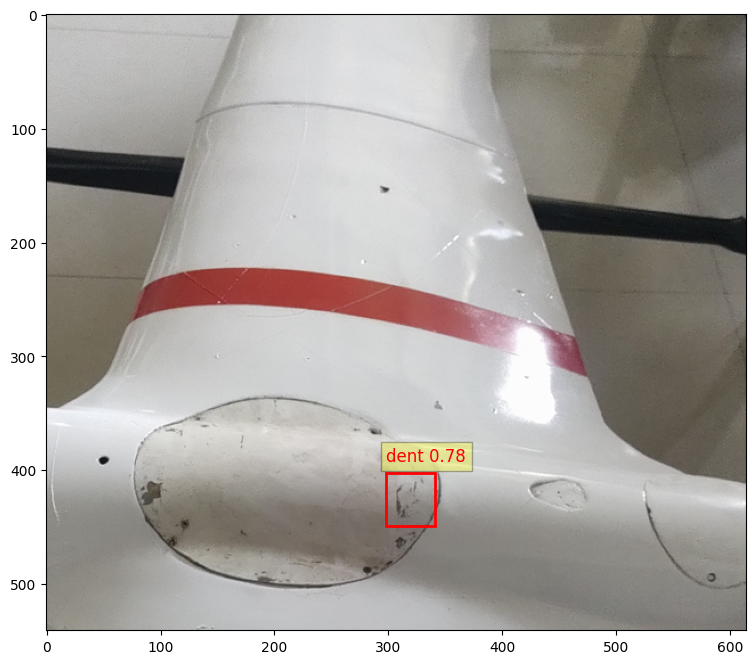

In [18]:
img_path = r"C:\Users\TE\Pictures\Screenshots\Screenshot 2025-09-12 124521.png"
image = Image.open(img_path).convert("RGB")
img_tensor = F.to_tensor(image).unsqueeze(0).to(device)

# Run inference
with torch.no_grad():
    outputs = model(img_tensor)

boxes = outputs[0]["boxes"].cpu()
labels = outputs[0]["labels"].cpu()
scores = outputs[0]["scores"].cpu()

# Visualization
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(image)

for box, label, score in zip(boxes, labels, scores):
    if score >= 0.3:  # filter low confidence detections
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor='r', facecolor="none")
        ax.add_patch(rect)

        label_name = CLASS_NAMES.get(label.item(), f"id:{label.item()}")
        ax.text(x1, y1-10, f"{label_name} {score:.2f}",
                color='red', fontsize=12,
                bbox=dict(facecolor='yellow', alpha=0.3))

plt.show()